# Simulating a Phospholipid Bilayer

Phospholipid bilayers are fundamental structures in biological membranes and are commonly studied using neutron and X-ray reflectometry.
In this tutorial, we will explore how to use the `Bilayer` assembly in `easyreflectometry` to model a lipid bilayer structure.

A bilayer consists of two surfactant layers arranged in an inverted configuration:

```
Head₁ - Tail₁ - Tail₂ - Head₂
```

The `Bilayer` assembly comes with pre-configured constraints that represent physically meaningful relationships:
- Both tail layers share the same structural parameters
- Head layers share thickness and area per molecule (but can have different hydration)
- Conformal roughness across all interfaces

## Setup

First, we import the necessary modules and configure matplotlib for inline plotting.

In [1]:
%matplotlib inline

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from easyreflectometry.calculators import CalculatorFactory
from easyreflectometry.model import Model
from easyreflectometry.model import PercentageFwhm
from easyreflectometry.sample import Bilayer
from easyreflectometry.sample import Layer
from easyreflectometry.sample import LayerAreaPerMolecule
from easyreflectometry.sample import Material
from easyreflectometry.sample import Multilayer
from easyreflectometry.sample import Sample

## Creating a Bilayer

We'll create a DPPC (dipalmitoylphosphatidylcholine) bilayer, a common model phospholipid.

First, let's define the solvent material — D₂O (heavy water) — which is used for all layers in the bilayer.

In [3]:
# Define the solvent material
d2o = Material(sld=6.36, isld=0, name='D2O')

### Creating Layer Components

Now we create the head and tail layers using `LayerAreaPerMolecule`. This approach allows us to define layers based on their chemical formula and area per molecule, which provides a more physically meaningful parameterization.

In [4]:
# Create a head layer for the bilayer
# The head group of DPPC has formula C10H18NO8P
head_layer = LayerAreaPerMolecule(
    molecular_formula='C10H18NO8P',
    thickness=10.0,
    solvent=d2o,
    solvent_fraction=0.3,  # 30% solvent in head region
    area_per_molecule=48.2,
    roughness=3.0,
    name='DPPC Head',
)

# Create a tail layer for the bilayer
# The tail group of deuterated DPPC has formula C32D64
front_tail_layer = LayerAreaPerMolecule(
    molecular_formula='C32D64',
    thickness=16.0,
    solvent=d2o,
    solvent_fraction=0.0,  # No solvent in the tail region
    area_per_molecule=48.2,
    roughness=3.0,
    name='DPPC Tail',
)

### Creating the Bilayer Assembly

Now we create the `Bilayer` assembly. The bilayer will automatically:
- Create a second tail layer with parameters constrained to the first
- Create a back head layer with thickness and area per molecule constrained to the front head
- Apply conformal roughness across all layers

In [5]:
# Create the bilayer with default constraints
bilayer = Bilayer(
    front_head_layer=head_layer,
    front_tail_layer=front_tail_layer,
    constrain_heads=True,  # Head layers share thickness and area per molecule
    conformal_roughness=True,  # All layers share the same roughness
    name='DPPC Bilayer',
)

print(bilayer)

DPPC Bilayer:
  front_head_layer:
    DPPC Head:
      material:
        C10H18NO8P in D2O:
          solvent_fraction: 0.300 dimensionless
          sld: 2.780e-6 1/Å^2
          isld: 0.000e-6 1/Å^2
          material:
            C10H18NO8P:
              sld: 1.246e-6 1/Å^2
              isld: 0.000e-6 1/Å^2
          solvent:
            D2O:
              sld: 6.360e-6 1/Å^2
              isld: 0.000e-6 1/Å^2
      thickness: 10.000 Å
      roughness: 3.000 Å
    molecular_formula: C10H18NO8P
    area_per_molecule: 48.20 Å^2
  front_tail_layer:
    DPPC Tail:
      material:
        C32D64 in D2O:
          solvent_fraction: 0.000 dimensionless
          sld: 8.292e-6 1/Å^2
          isld: 0.000e-6 1/Å^2
          material:
            C32D64:
              sld: 8.292e-6 1/Å^2
              isld: 0.000e-6 1/Å^2
          solvent:
            D2O:
              sld: 6.360e-6 1/Å^2
              isld: 0.000e-6 1/Å^2
      thickness: 16.000 Å
      roughness: 3.000 Å
    molecular_f

## Exploring the Bilayer Structure

Let's examine the layer structure of our bilayer.

In [6]:
# The bilayer has 4 layers: front_head, front_tail, back_tail, back_head
# All structural parameters are automatically constrained
print(f'Bilayer layers: {len(bilayer.layers)}')

Bilayer layers: 4


### Verifying Constraints

The `Bilayer` assembly provides access to all four sub-layers through the properties `front_head_layer`, `front_tail_layer`, `back_tail_layer`, and `back_head_layer`. The back tail and back head layers are automatically created by the assembly, with their structural parameters constrained to the corresponding front layers. Let's verify that the constraints are working correctly.

In [7]:
# Access key structural parameters
print(f'Head thickness: {bilayer.front_head_layer.thickness.value:.2f} Å')
print(f'Tail thickness: {bilayer.front_tail_layer.thickness.value:.2f} Å')
print(f'Area per molecule: {bilayer.front_head_layer.area_per_molecule.value:.2f} Å²')

Head thickness: 10.00 Å
Tail thickness: 16.00 Å
Area per molecule: 48.20 Å²


### Independent Head Layer Hydration

While `constrain_heads=True` links the head layers' thicknesses and areas per molecule, the solvent fraction (hydration) of each head layer remains independent. This is physically meaningful — in a supported bilayer, the head group facing the substrate may have different hydration than the one facing the bulk solvent. We can access the front and back head layers through `bilayer.front_head_layer` and `bilayer.back_head_layer`.

In [8]:
# Head layers share thickness and area per molecule via constrain_heads=True,
# but solvent fraction is independent and can be set separately for each side.
print(f'Front head solvent fraction: {bilayer.front_head_layer.solvent_fraction.value:.2f}')
print(f'Back head solvent fraction:  {bilayer.back_head_layer.solvent_fraction.value:.2f}')

# We can set them independently
bilayer.back_head_layer.solvent_fraction = 0.5
print('\nAfter setting back head solvent fraction to 0.5:')
print(f'Front head solvent fraction: {bilayer.front_head_layer.solvent_fraction.value:.2f}')
print(f'Back head solvent fraction:  {bilayer.back_head_layer.solvent_fraction.value:.2f}')

Front head solvent fraction: 0.30
Back head solvent fraction:  0.20

After setting back head solvent fraction to 0.5:
Front head solvent fraction: 0.30
Back head solvent fraction:  0.50


### Conformal Roughness

When `conformal_roughness=True`, all four layers in the bilayer share the same roughness value, controlled by the front head layer's roughness parameter. Let's verify this by printing the roughness of each layer.

In [9]:
# Conformal roughness: all layers share the same roughness value
# (controlled by the front head layer)
print(f'Front head roughness: {bilayer.front_head_layer.roughness.value:.2f} Å')
print(f'Front tail roughness: {bilayer.front_tail_layer.roughness.value:.2f} Å')
print(f'Back tail roughness:  {bilayer.back_tail_layer.roughness.value:.2f} Å')
print(f'Back head roughness:  {bilayer.back_head_layer.roughness.value:.2f} Å')

Front head roughness: 3.00 Å
Front tail roughness: 3.00 Å
Back tail roughness:  3.00 Å
Back head roughness:  3.00 Å


## Building a Complete Sample

To simulate reflectometry, we need to create a complete sample with sub- and super-phases.

In [10]:
# Reset bilayer parameters
bilayer.front_head_layer.roughness.value = 3.0
bilayer.front_tail_layer.thickness.value = 16.0
bilayer.back_head_layer.solvent_fraction = 0.3

# Create substrate layers (silicon with oxide layer)
si = Material(sld=2.047, isld=0, name='Si')
sio2 = Material(sld=3.47, isld=0, name='SiO2')
si_layer = Layer(material=si, thickness=0, roughness=0, name='Si Substrate')
sio2_layer = Layer(material=sio2, thickness=15, roughness=3, name='SiO2')

# D2O subphase (bulk water)
d2o_subphase = Layer(material=d2o, thickness=0, roughness=3, name='D2O Bulk')

# Create sample structure: Si | SiO2 | head | tail | tail | head | D2O
# In easyreflectometry convention: superphase (Si) -> layers -> subphase (D2O)
sample = Sample(
    Multilayer(si_layer, name='Si Substrate'),
    Multilayer(sio2_layer, name='SiO2'),
    bilayer,
    Multilayer(d2o_subphase, name='D2O Subphase'),
    name='Bilayer on Si/SiO2',
)

print(sample)

Bilayer on Si/SiO2:
- Si Substrate:
    Si Substrate:
    - Si Substrate:
        material:
          Si:
            sld: 2.047e-6 1/Å^2
            isld: 0.000e-6 1/Å^2
        thickness: 0.000 Å
        roughness: 0.000 Å
- SiO2:
    SiO2:
    - SiO2:
        material:
          SiO2:
            sld: 3.470e-6 1/Å^2
            isld: 0.000e-6 1/Å^2
        thickness: 15.000 Å
        roughness: 3.000 Å
- DPPC Bilayer:
    front_head_layer:
      DPPC Head:
        material:
          C10H18NO8P in D2O:
            solvent_fraction: 0.300 dimensionless
            sld: 2.780e-6 1/Å^2
            isld: 0.000e-6 1/Å^2
            material:
              C10H18NO8P:
                sld: 1.246e-6 1/Å^2
                isld: 0.000e-6 1/Å^2
            solvent:
              D2O:
                sld: 6.360e-6 1/Å^2
                isld: 0.000e-6 1/Å^2
        thickness: 10.000 Å
        roughness: 3.000 Å
      molecular_formula: C10H18NO8P
      area_per_molecule: 48.20 Å^2
    front_tail

## Simulating Reflectivity

Now we can simulate the reflectometry profile for our bilayer sample.

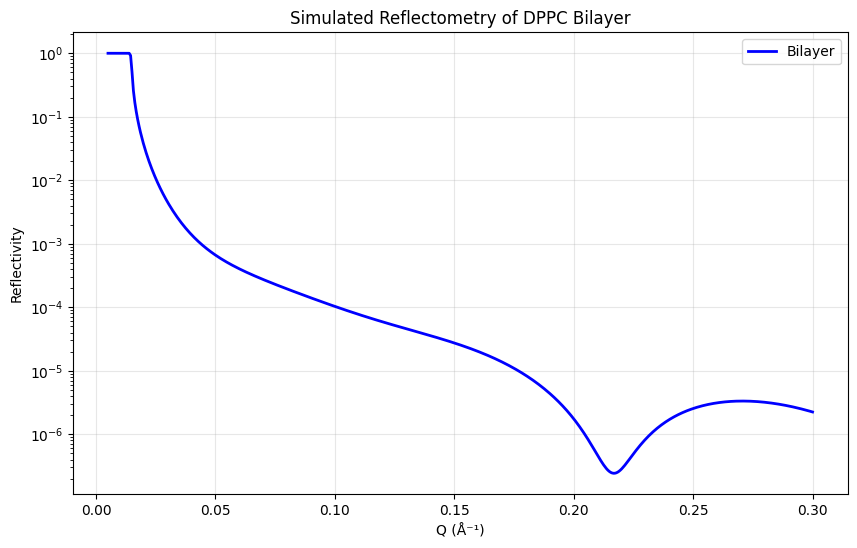

In [11]:
# Create the model
model = Model(sample=sample, scale=1.0, background=1e-7, resolution_function=PercentageFwhm(5), name='Bilayer Model')

# Set up the calculator
interface = CalculatorFactory()
model.interface = interface

# Generate Q values
q = np.linspace(0.005, 0.3, 500)

# Calculate reflectometry
reflectivity = model.interface().reflectity_profile(q, model.unique_name)

# Plot
plt.figure(figsize=(10, 6))
plt.semilogy(q, reflectivity, 'b-', linewidth=2, label='Bilayer')
plt.xlabel('Q (Å⁻¹)')
plt.ylabel('Reflectivity')
plt.title('Simulated Reflectometry of DPPC Bilayer')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Scattering Length Density Profile

Let's also visualize the SLD profile of our bilayer structure.

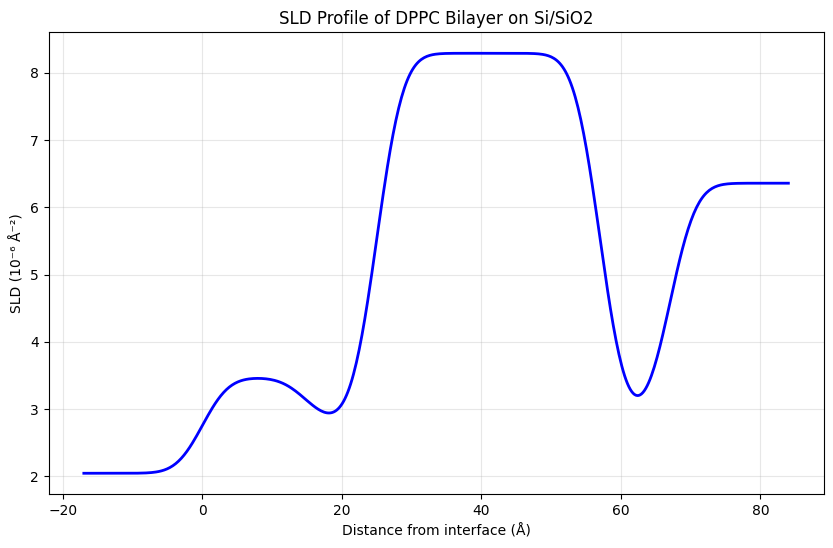

In [12]:
# Get SLD profile
z, sld = model.interface().sld_profile(model.unique_name)

plt.figure(figsize=(10, 6))
plt.plot(z, sld, 'b-', linewidth=2)
plt.xlabel('Distance from interface (Å)')
plt.ylabel('SLD (10⁻⁶ Å⁻²)')
plt.title('SLD Profile of DPPC Bilayer on Si/SiO2')
plt.grid(True, alpha=0.3)
plt.show()

## Modifying Constraints

The bilayer constraints can be modified at runtime. Let's see how disabling conformal roughness affects the model.

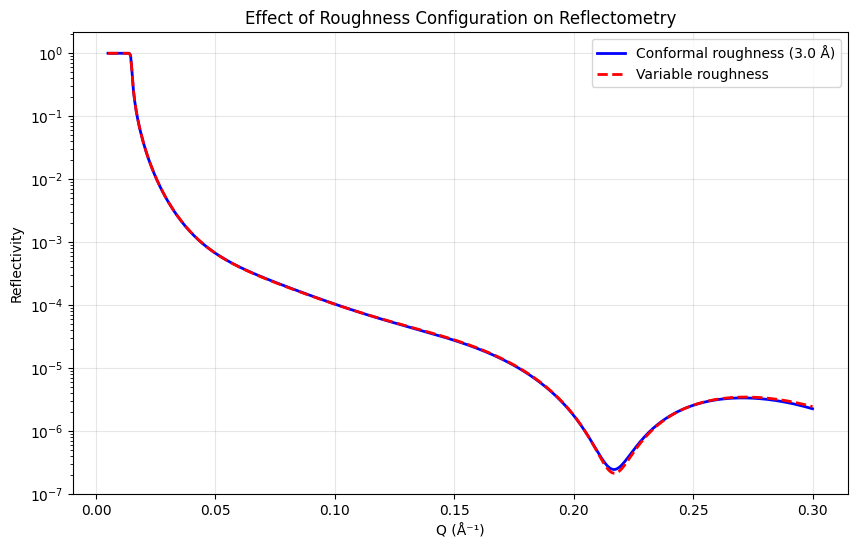

In [13]:
# First, compute reflectivity with current conformal roughness (3.0 Å)
reflectivity_conformal = model.interface().reflectity_profile(q, model.unique_name)

# Disable conformal roughness to allow independent roughness per layer
bilayer.conformal_roughness = False

# Re-establish calculator bindings after constraint change
model.generate_bindings()

# Set varying roughness across the bilayer
bilayer.front_head_layer.roughness.value = 2.0
bilayer.front_tail_layer.roughness.value = 1.5
bilayer.back_tail_layer.roughness.value = 1.5
bilayer.back_head_layer.roughness.value = 4.0

# Compute reflectivity with variable roughness
reflectivity_variable_roughness = model.interface().reflectity_profile(q, model.unique_name)

# Plot comparison
plt.figure(figsize=(10, 6))
plt.semilogy(q, reflectivity_conformal, 'b-', linewidth=2, label='Conformal roughness (3.0 Å)')
plt.semilogy(q, reflectivity_variable_roughness, 'r--', linewidth=2, label='Variable roughness')
plt.xlabel('Q (Å⁻¹)')
plt.ylabel('Reflectivity')
plt.title('Effect of Roughness Configuration on Reflectometry')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Reset to conformal roughness for subsequent cells
bilayer.conformal_roughness = True
bilayer.front_head_layer.roughness.value = 3.0
model.generate_bindings()

## Asymmetric Hydration

One of the key features of the `Bilayer` assembly is the ability to model asymmetric hydration - where the two sides of the bilayer have different solvent exposure.

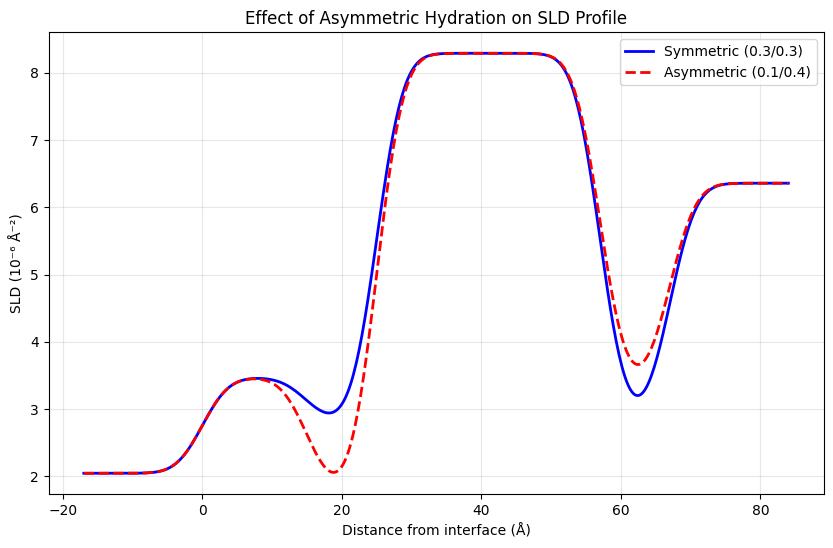

In [14]:
# Asymmetric hydration: different solvent exposure on each side
# Set up symmetric hydration first
bilayer.front_head_layer.solvent_fraction = 0.3
bilayer.back_head_layer.solvent_fraction = 0.3

# Get symmetric SLD profile
z_sym, sld_sym = model.interface().sld_profile(model.unique_name)

# Now set asymmetric hydration (common in supported bilayers)
bilayer.front_head_layer.solvent_fraction = 0.1  # Substrate side - less hydrated
bilayer.back_head_layer.solvent_fraction = 0.4  # Solution side - more hydrated

# Get asymmetric SLD profile
z_asym, sld_asym = model.interface().sld_profile(model.unique_name)

# Plot comparison
plt.figure(figsize=(10, 6))
plt.plot(z_sym, sld_sym, 'b-', linewidth=2, label='Symmetric (0.3/0.3)')
plt.plot(z_asym, sld_asym, 'r--', linewidth=2, label='Asymmetric (0.1/0.4)')
plt.xlabel('Distance from interface (Å)')
plt.ylabel('SLD (10⁻⁶ Å⁻²)')
plt.title('Effect of Asymmetric Hydration on SLD Profile')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Multiple Contrast Analysis

The most common use case for bilayer models is fitting multiple contrast data - measuring the same sample with different isotopic compositions of the solvent (e.g., D₂O, H₂O, or mixtures).

The `Bilayer` assembly provides a `constrain_multiple_contrast` method to link structural parameters across different contrast measurements while allowing contrast-specific parameters (like solvent fraction) to vary independently.

In [15]:
# Reset bilayer to symmetric hydration
bilayer.front_head_layer.solvent_fraction = 0.3
bilayer.back_head_layer.solvent_fraction = 0.3

# Create H2O material for second contrast
h2o = Material(sld=-0.56, isld=0, name='H2O')

# Create head layer for H2O contrast (same lipid, different solvent)
head_layer_h2o = LayerAreaPerMolecule(
    molecular_formula='C10H18NO8P',
    thickness=10.0,
    solvent=h2o,
    solvent_fraction=0.3,
    area_per_molecule=48.2,
    roughness=3.0,
    name='DPPC Head H2O',
)

# Create tail layer for H2O contrast (same deuterated lipid, different solvent)
tail_layer_h2o = LayerAreaPerMolecule(
    molecular_formula='C32D64',
    thickness=16.0,
    solvent=h2o,
    solvent_fraction=0.0,
    area_per_molecule=48.2,
    roughness=3.0,
    name='DPPC Tail H2O',
)

# Create H2O bilayer
bilayer_h2o = Bilayer(
    front_head_layer=head_layer_h2o,
    front_tail_layer=tail_layer_h2o,
    constrain_heads=True,
    conformal_roughness=True,
    name='DPPC Bilayer H2O',
)

In [16]:
# Constrain structural parameters between contrasts
# Link thicknesses and areas per molecule, but NOT solvent fractions
bilayer_h2o.constrain_multiple_contrast(
    bilayer,
    front_head_thickness=True,
    back_head_thickness=True,
    tail_thickness=True,
    front_head_area_per_molecule=True,
    back_head_area_per_molecule=True,
    tail_area_per_molecule=True,
    front_head_fraction=False,  # Hydration can differ between contrasts
    back_head_fraction=False,
    tail_fraction=False,
)

print('Structural parameters are now constrained between D2O and H2O contrasts')
print(f'D2O head thickness: {bilayer.front_head_layer.thickness.value:.2f} Å')
print(f'H2O head thickness: {bilayer_h2o.front_head_layer.thickness.value:.2f} Å')

Structural parameters are now constrained between D2O and H2O contrasts
D2O head thickness: 10.00 Å
H2O head thickness: 10.00 Å


In [17]:
# Create complete sample for H2O contrast
h2o_subphase = Layer(material=h2o, thickness=0, roughness=3, name='H2O Subphase')

sample_h2o = Sample(
    Multilayer(si_layer, name='Si Substrate'),
    Multilayer(sio2_layer, name='SiO2'),
    bilayer_h2o,
    Multilayer(h2o_subphase, name='H2O Subphase'),
    name='Bilayer on Si/SiO2 in H2O',
)

# Create model for H2O contrast
model_h2o = Model(
    sample=sample_h2o, scale=1.0, background=1e-7, resolution_function=PercentageFwhm(5), name='Bilayer Model H2O'
)
model_h2o.interface = interface

### SLD Profiles: D₂O vs H₂O Contrast

The SLD profiles clearly show the difference in contrast between D₂O and H₂O measurements.

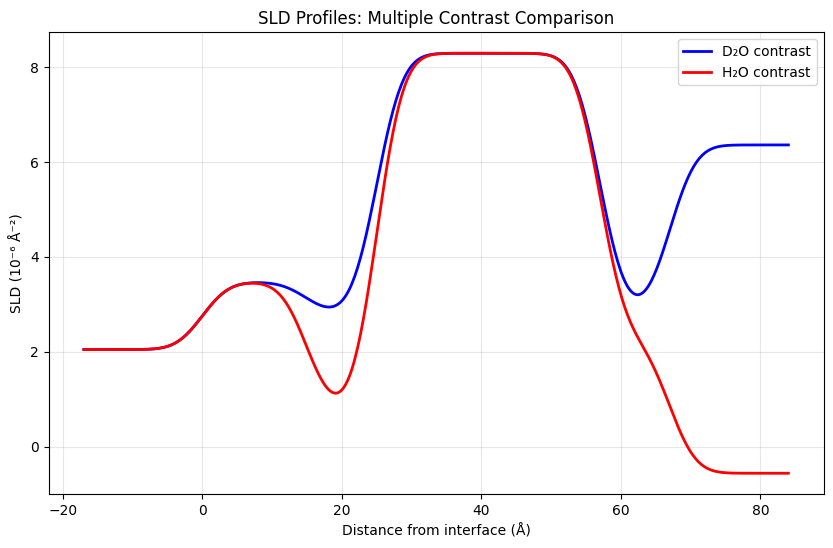

In [18]:
# Get SLD profiles for both contrasts
z_d2o, sld_d2o = model.interface().sld_profile(model.unique_name)
z_h2o, sld_h2o = model_h2o.interface().sld_profile(model_h2o.unique_name)

plt.figure(figsize=(10, 6))
plt.plot(z_d2o, sld_d2o, 'b-', linewidth=2, label='D₂O contrast')
plt.plot(z_h2o, sld_h2o, 'r-', linewidth=2, label='H₂O contrast')
plt.xlabel('Distance from interface (Å)')
plt.ylabel('SLD (10⁻⁶ Å⁻²)')
plt.title('SLD Profiles: Multiple Contrast Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Reflectivity Curves: D₂O vs H₂O Contrast

The reflectivity curves show how the different contrasts provide complementary structural information.

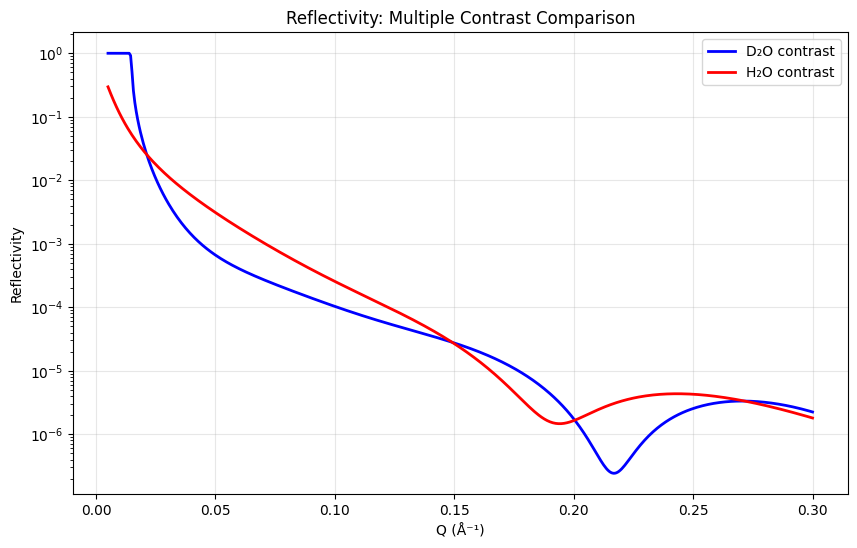

In [19]:
# Calculate reflectivity for both contrasts
reflectivity_d2o = model.interface().reflectity_profile(q, model.unique_name)
reflectivity_h2o = model_h2o.interface().reflectity_profile(q, model_h2o.unique_name)

plt.figure(figsize=(10, 6))
plt.semilogy(q, reflectivity_d2o, 'b-', linewidth=2, label='D₂O contrast')
plt.semilogy(q, reflectivity_h2o, 'r-', linewidth=2, label='H₂O contrast')
plt.xlabel('Q (Å⁻¹)')
plt.ylabel('Reflectivity')
plt.title('Reflectivity: Multiple Contrast Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Summary

In this tutorial, we explored the `Bilayer` assembly in `easyreflectometry`:

1. **Creating a bilayer**: Using `LayerAreaPerMolecule` components for head and tail layers
2. **Built-in constraints**: 
   - Tail layers share all structural parameters
   - Head layers share thickness and area per molecule (hydration is independent)
   - Conformal roughness applies to all layers by default
3. **Building a sample**: Combining the bilayer with sub- and super-phases (Si/SiO₂ substrate, water subphase)
4. **Simulating reflectometry**: Using the calculator interface to generate reflectivity and SLD profiles
5. **Asymmetric hydration**: Modeling supported bilayers with different solvent exposure on each side
6. **Multiple contrast analysis**: 
   - Creating bilayers with different solvent contrasts (D₂O/H₂O)
   - Using `constrain_multiple_contrast` to link structural parameters across contrasts
   - Visualizing complementary information from different contrasts

The `Bilayer` assembly provides a convenient way to model phospholipid bilayers with physically meaningful constraints, making it ideal for simultaneous fitting of multiple contrast reflectometry data.